### importing required packages

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import utils.util as util

pd.set_option('display.max_columns', None)

## importing cleaned dataset

In [3]:
df = pd.read_csv('../data/interim/cleaned_data.csv')
df.head()

,student_id,age,gender,first_generation_college,international_student,residency_status,high_school_gpa,sat_score,act_score,advanced_courses_taken,extracurricular_activities,major,enrollment_status,semester_credits,admission_type,starting_semester,family_income,financial_aid_received,pell_grant_eligible,student_loan_amount,has_campus_job,current_gpa,credits_completed,courses_failed,courses_withdrawn,attendance_rate,study_hours_per_week,library_visits_per_month,tutoring_sessions_attended,advisor_meetings,clubs_joined,living_arrangement,has_disability,distance_from_campus_miles,work_hours_per_week,dropped_out
0,1,23,Male,False,False,In-state,2.88,1034.0,26,2,2,Health Sciences,Full-time,12,Transfer,Fall,$30k-$60k,True,False,239,True,3.63,23,0,0,73.6,21,0,0,3,0,On-campus,False,64,18,False
1,2,20,Male,True,False,In-state,2.79,1162.0,20,3,2,Social Sciences,Full-time,18,Regular,Spring,$60k-$100k,False,True,24364,False,1.92,45,2,3,77.6,11,4,2,1,2,On-campus,False,0,2,True
2,3,19,Female,False,False,In-state,3.44,1264.0,22,5,2,Arts & Sciences,Full-time,12,Regular,Fall,$60k-$100k,True,False,18313,True,2.13,96,0,0,69.9,28,2,2,1,0,On-campus,False,10,5,True
3,4,17,Male,False,True,In-state,2.86,966.0,28,4,3,Engineering,Full-time,18,Regular,Fall,$30k-$60k,True,False,11918,True,3.22,3,0,1,83.8,24,1,0,0,1,Off-campus,False,24,27,False
4,5,17,Male,True,True,Out-of-state,3.77,1174.0,25,8,1,Business,Full-time,15,Early Decision,Fall,$30k-$60k,True,False,6449,False,3.18,1,1,1,79.8,7,7,5,1,0,On-campus,False,15,10,False


In [4]:
df['family_income'].unique()

array(['$30k-$60k', '$60k-$100k', '<$30k', '$100k+'], dtype=object)

### creating new feature called as income group to easily find the relationship between family income and dropouts

In [5]:
df['income_group'] = df['family_income'].replace({
    '<$30k': 'Low',
    '$30k-$60k': 'Medium',
    '$60k-$100k': 'Medium',
    '$100k+': 'High'
})

In [6]:
pd.crosstab(df['income_group'], df['dropped_out'], normalize='index')

dropped_out,False,True
income_group,,
High,0.665621,0.334379
Low,0.528538,0.471462
Medium,0.684430,0.315570


<Axes: xlabel='income_group'>

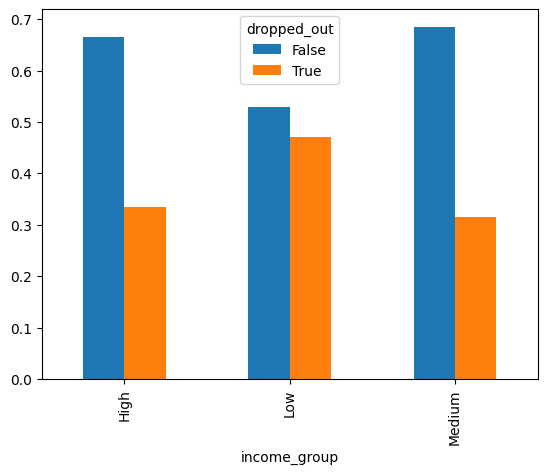

In [7]:
pd.crosstab(df['income_group'], df['dropped_out'], normalize='index').plot(kind='bar')

Low income students show significantly higher dropout (~47%) 
compared to medium and high income groups (~31–33%).

In [8]:
df.head()

,student_id,age,gender,first_generation_college,international_student,residency_status,high_school_gpa,sat_score,act_score,advanced_courses_taken,extracurricular_activities,major,enrollment_status,semester_credits,admission_type,starting_semester,family_income,financial_aid_received,pell_grant_eligible,student_loan_amount,has_campus_job,current_gpa,credits_completed,courses_failed,courses_withdrawn,attendance_rate,study_hours_per_week,library_visits_per_month,tutoring_sessions_attended,advisor_meetings,clubs_joined,living_arrangement,has_disability,distance_from_campus_miles,work_hours_per_week,dropped_out,income_group
0,1,23,Male,False,False,In-state,2.88,1034.0,26,2,2,Health Sciences,Full-time,12,Transfer,Fall,$30k-$60k,True,False,239,True,3.63,23,0,0,73.6,21,0,0,3,0,On-campus,False,64,18,False,Medium
1,2,20,Male,True,False,In-state,2.79,1162.0,20,3,2,Social Sciences,Full-time,18,Regular,Spring,$60k-$100k,False,True,24364,False,1.92,45,2,3,77.6,11,4,2,1,2,On-campus,False,0,2,True,Medium
2,3,19,Female,False,False,In-state,3.44,1264.0,22,5,2,Arts & Sciences,Full-time,12,Regular,Fall,$60k-$100k,True,False,18313,True,2.13,96,0,0,69.9,28,2,2,1,0,On-campus,False,10,5,True,Medium
3,4,17,Male,False,True,In-state,2.86,966.0,28,4,3,Engineering,Full-time,18,Regular,Fall,$30k-$60k,True,False,11918,True,3.22,3,0,1,83.8,24,1,0,0,1,Off-campus,False,24,27,False,Medium
4,5,17,Male,True,True,Out-of-state,3.77,1174.0,25,8,1,Business,Full-time,15,Early Decision,Fall,$30k-$60k,True,False,6449,False,3.18,1,1,1,79.8,7,7,5,1,0,On-campus,False,15,10,False,Medium


## academic column group
high_school_gpa, current_gpa, sat_score, act_score, courses_failed, courses_withdrawn, advanced_courses_taken

In [18]:
academic_cols = ['high_school_gpa', 'current_gpa', 'sat_score', 'act_score', 'courses_failed', 'courses_withdrawn', 'advanced_courses_taken']

summary = []

for col in academic_cols:
    res = df.groupby('dropped_out')[col].mean()
    summary.append({
        'column': col,
        'not_dropped': res[0],
        'dropped': res[1]
    })

summary_df = pd.DataFrame(summary)
summary_df

/var/folders/47/spc9kf0x5xngx2jj19_8vgj00000gn/T/ipykernel_21634/3935617191.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'not_dropped': res[0],
/var/folders/47/spc9kf0x5xngx2jj19_8vgj00000gn/T/ipykernel_21634/3935617191.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'dropped': res[1]


,column,not_dropped,dropped
0,high_school_gpa,3.290851,3.282569
1,current_gpa,2.941528,2.759657
2,sat_score,1150.398579,1154.370429
3,act_score,23.549784,23.575218
4,courses_failed,0.688644,1.001516
5,courses_withdrawn,0.490948,0.486927
6,advanced_courses_taken,3.001029,2.994316


Among academic features, current GPA and number of failed courses show a noticeable relationship with dropout. Students who dropped out tend to have lower GPA and higher number of failed courses.

On the other hand, high school GPA, SAT/ACT scores, and advanced courses taken do not show significant differences, indicating weak or no relationship with dropout.

## creating new feature called 'academic_risk' by combining 'current_gpa' and 'courses_failed'

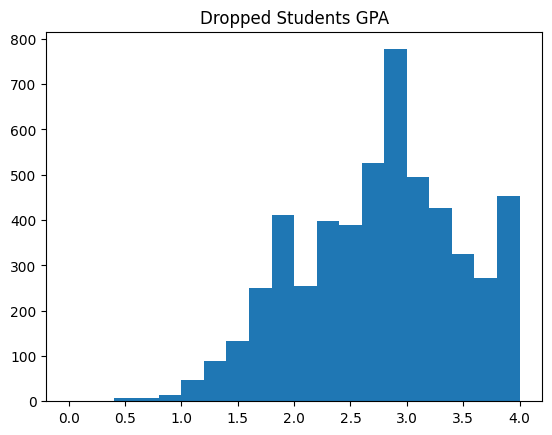

In [20]:
import matplotlib.pyplot as plt

plt.hist(df[df['dropped_out']==1]['current_gpa'], bins=20)
plt.title("Dropped Students GPA")
plt.show()

In [ ]:
df['courses_failed'].value_counts()

courses_failed
0    6778
1    5358
2    2151
3     565
4     119
5      25
6       3
7       1
Name: count, dtype: int64

In [23]:
gpa_threshold = df['current_gpa'].quantile(0.25)
gpa_threshold

df['academic_risk'] = (
    (df['current_gpa'] < gpa_threshold) |
    (df['courses_failed'] >= 1)
)

df['academic_risk'].value_counts()

academic_risk
True     9906
False    5094
Name: count, dtype: int64

In [24]:
pd.crosstab(df['academic_risk'], df['dropped_out'], normalize='index')

dropped_out,False,True
academic_risk,,
False,0.726345,0.273655
True,0.607914,0.392086
